# Project 2 — Bipartite Network Analysis: MovieLens 100K
**DATA 620 — Web Analytics | Summer 2026**

**Dataset:** MovieLens 100K (grouplens.org) — 943 users × 1,682 movies, 100,000 ratings

**Two distinct groups:** Users (raters) and Movies (items being rated). Edges only connect users to movies — never user-to-user or movie-to-movie, making this a true bipartite network.

**Approach:**
1. Build the full bipartite graph with ratings as edge weights
2. Reduce the network using the island method (retain only high ratings)
3. Analyze each group separately using bipartite-aware centrality
4. Project onto each mode and detect communities
5. Infer what each group reveals about the other

## 1. Setup

In [173]:
# Core data manipulation
import numpy as np
import pandas as pd

# Graph analysis
import networkx as nx
from networkx.algorithms import bipartite
from networkx.algorithms.community import greedy_modularity_communities

# Visualization
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns

# Data download and file handling
import urllib.request
import zipfile
import os
import math
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
SEED = 45   # used for reproducible layouts

print('Libraries loaded.')

Libraries loaded.


## 2. Data Loading

In [174]:
DATA_DIR = './ml-100k'
ZIP_URL  = 'https://files.grouplens.org/datasets/movielens/ml-100k.zip'

# Download and unzip only if the data folder doesn't already exist
if not os.path.exists(DATA_DIR):
    print('Downloading MovieLens 100K...')
    urllib.request.urlretrieve(ZIP_URL, 'ml-100k.zip')
    with zipfile.ZipFile('ml-100k.zip', 'r') as z:
        z.extractall('.')
    os.remove('ml-100k.zip')   # clean up the zip after extraction
    print('Done.')
else:
    print('Data already present.')

Data already present.


In [175]:
# Load the main ratings file (tab-separated, no header)
ratings = pd.read_csv(
    f'{DATA_DIR}/u.data', sep='\t',
    names=['user_id', 'movie_id', 'rating', 'timestamp']
)

# Load movie metadata — pipe-separated, latin-1 encoding for special characters
genre_cols = ['unknown','Action','Adventure','Animation','Childrens','Comedy',
              'Crime','Documentary','Drama','Fantasy','Film-Noir','Horror',
              'Musical','Mystery','Romance','Sci-Fi','Thriller','War','Western']
movie_info = pd.read_csv(
    f'{DATA_DIR}/u.item', sep='|', encoding='latin-1',
    names=['movie_id','title','release_date','video_date','imdb_url'] + genre_cols
)

# Prefix IDs so user node '1' and movie node '1' are distinct objects in the graph
ratings['user_node']  = 'U_' + ratings['user_id'].astype(str)
ratings['movie_node'] = 'M_' + ratings['movie_id'].astype(str)

# Build a lookup dict for movie titles by prefixed node ID
movie_title = dict(zip('M_' + movie_info['movie_id'].astype(str), movie_info['title']))

print(f'Ratings loaded: {len(ratings):,}')
print(f'Unique users:   {ratings["user_id"].nunique()}')
print(f'Unique movies:  {ratings["movie_id"].nunique()}')
ratings.head()

Ratings loaded: 100,000
Unique users:   943
Unique movies:  1682


,user_id,movie_id,rating,timestamp,user_node,movie_node
0,196,242,3,881250949,U_196,M_242
1,186,302,3,891717742,U_186,M_302
2,22,377,1,878887116,U_22,M_377
3,244,51,2,880606923,U_244,M_51
4,166,346,1,886397596,U_166,M_346


## 3. Bipartite Graph Construction

In [176]:
# Collect unique node lists for each group
all_user_nodes  = ratings['user_node'].unique().tolist()
all_movie_nodes = ratings['movie_node'].unique().tolist()

# Initialize graph and add nodes with bipartite group labels
G = nx.Graph()
G.add_nodes_from(all_user_nodes,  bipartite=0)   # group 0 = users
G.add_nodes_from(all_movie_nodes, bipartite=1)   # group 1 = movies

# Add an edge for every rating; store the rating value as edge weight
for _, row in ratings.iterrows():
    G.add_edge(row['user_node'], row['movie_node'], weight=row['rating'])

print(f'Bipartite check: {nx.is_bipartite(G)}')
print(f'Nodes: {G.number_of_nodes():,}  (users: {len(all_user_nodes)}, movies: {len(all_movie_nodes)})')
print(f'Edges: {G.number_of_edges():,}')
# bipartite.density normalizes by (|U| × |V|) — the correct denominator for a 2-mode graph
print(f'Bipartite density: {bipartite.density(G, all_user_nodes):.5f}')
print(f'(General graph density for reference: {nx.density(G):.5f})')


Bipartite check: True
Nodes: 2,625  (users: 943, movies: 1682)
Edges: 100,000
Bipartite density: 0.06305
(General graph density for reference: 0.02904)


## 4. Island Method — Network Reduction

The island method retains only edges above a weight threshold, leaving behind "islands" — subgraphs of nodes connected by strong ties. Here, edge weight is the rating (1–5). Keeping only ratings ≥ 4 means retaining edges that represent genuine enthusiasm, not indifference or obligation. This is a theoretically motivated threshold, not arbitrary.

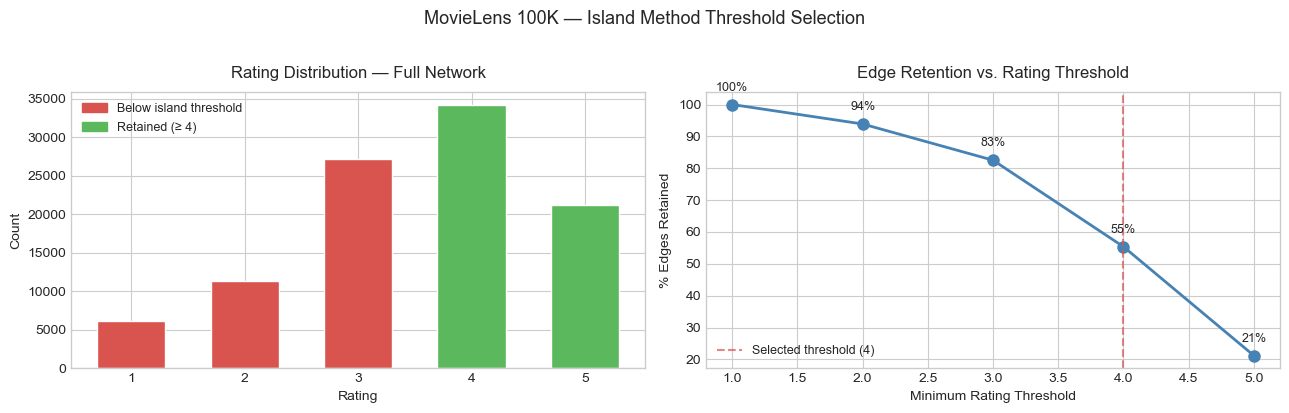

In [177]:
# Compute how many edges survive at each possible threshold
thresholds   = [1, 2, 3, 4, 5]
edge_counts  = [sum(1 for u, v, d in G.edges(data=True) if d['weight'] >= t) for t in thresholds]
edge_pcts    = [c / G.number_of_edges() * 100 for c in edge_counts]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: show the overall rating distribution, color-coded by threshold selection
rating_counts = ratings['rating'].value_counts().sort_index()
bar_colors = ['#d9534f' if r < 4 else '#5cb85c' for r in rating_counts.index]
axes[0].bar(rating_counts.index, rating_counts.values, color=bar_colors, edgecolor='white', width=0.6)
axes[0].set_title('Rating Distribution — Full Network', fontsize=12, pad=10)
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
axes[0].legend(handles=[
    plt.Rectangle((0,0),1,1, color='#d9534f', label='Below island threshold'),
    plt.Rectangle((0,0),1,1, color='#5cb85c', label='Retained (≥ 4)')
], loc='upper left', fontsize=9)

# Right: show the edge retention curve — helps justify the chosen threshold visually
axes[1].plot(thresholds, edge_pcts, 'o-', color='steelblue', linewidth=2, markersize=8)
axes[1].axvline(x=4, color='#d9534f', linestyle='--', alpha=0.7, label='Selected threshold (4)')
axes[1].set_title('Edge Retention vs. Rating Threshold', fontsize=12, pad=10)
axes[1].set_xlabel('Minimum Rating Threshold')
axes[1].set_ylabel('% Edges Retained')
axes[1].legend(fontsize=9)
for t, pct in zip(thresholds, edge_pcts):
    axes[1].annotate(f'{pct:.0f}%', (t, pct), textcoords='offset points', xytext=(0, 10), ha='center', fontsize=9)

plt.suptitle('MovieLens 100K — Island Method Threshold Selection', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [178]:
ISLAND_THRESHOLD = 4

# Keep only edges at or above the threshold
island_edges = [
    (u, v, d) for u, v, d in G.edges(data=True)
    if d['weight'] >= ISLAND_THRESHOLD
]

# Build reduced graph, preserving bipartite group labels on all nodes
G_island = nx.Graph()
G_island.add_nodes_from(all_user_nodes,  bipartite=0)
G_island.add_nodes_from(all_movie_nodes, bipartite=1)
G_island.add_edges_from(island_edges)

# Remove users/movies that have no edges after filtering (isolated nodes add no information)
isolated = list(nx.isolates(G_island))
G_island.remove_nodes_from(isolated)

# Re-extract node lists from the reduced graph
island_user_nodes  = [n for n, d in G_island.nodes(data=True) if d.get('bipartite') == 0]
island_movie_nodes = [n for n, d in G_island.nodes(data=True) if d.get('bipartite') == 1]

print(f'--- Island Method (rating >= {ISLAND_THRESHOLD}) ---')
print(f'Edges retained : {G_island.number_of_edges():,} of {G.number_of_edges():,} ({G_island.number_of_edges()/G.number_of_edges()*100:.1f}%)')
print(f'Users retained : {len(island_user_nodes)} of {len(all_user_nodes)}')
print(f'Movies retained: {len(island_movie_nodes)} of {len(all_movie_nodes)}')
print(f'Connected components: {nx.number_connected_components(G_island)}')
print(f'Largest component: {max(len(c) for c in nx.connected_components(G_island))} nodes')

--- Island Method (rating >= 4) ---
Edges retained : 55,375 of 100,000 (55.4%)
Users retained : 942 of 943
Movies retained: 1447 of 1682
Connected components: 1
Largest component: 2389 nodes


In [179]:
# Profile what the island method removes — makes the reduction more analytical
dropped_movie_nodes = set(all_movie_nodes) - set(island_movie_nodes)
dropped_user_nodes  = set(all_user_nodes)  - set(island_user_nodes)

# Numeric IDs for genre lookup
dropped_movie_ids = [int(n.replace('M_','')) for n in dropped_movie_nodes]
kept_movie_ids    = [int(n.replace('M_','')) for n in island_movie_nodes]
real_genres       = [g for g in genre_cols if g != 'unknown']   # drop the 'unknown' column
movie_genre_data  = movie_info.set_index('movie_id')[real_genres]

# Genre share comparison — which genres are overrepresented in dropped movies?
dropped_genre_pct = movie_genre_data.loc[movie_genre_data.index.isin(dropped_movie_ids)].mean() * 100
kept_genre_pct    = movie_genre_data.loc[movie_genre_data.index.isin(kept_movie_ids)].mean()    * 100

genre_compare = pd.DataFrame({
    'Dropped % (235 movies)':  dropped_genre_pct.round(1),
    'Retained % (1447 movies)': kept_genre_pct.round(1)
}).sort_values('Dropped % (235 movies)', ascending=False)
genre_compare.index.name = 'Genre'

print(f'Movies removed by island method: {len(dropped_movie_nodes)} of {len(all_movie_nodes)}')
print(f'Users removed by island method:  {len(dropped_user_nodes)} of {len(all_user_nodes)}')
print()
print('Genre distribution — dropped vs. retained movies (% in each genre):')
print(genre_compare.to_string())
print()
print('Genres with higher share in dropped movies received no ≥4 ratings in this dataset.')


Movies removed by island method: 235 of 1682
Users removed by island method:  1 of 943

Genre distribution — dropped vs. retained movies (% in each genre):
             Dropped % (235 movies)  Retained % (1447 movies)
Genre                                                        
Drama                          48.1                      42.3
Comedy                         27.2                      30.5
Action                         11.5                      15.5
Thriller                       11.1                      15.5
Romance                         9.4                      15.5
Crime                           6.4                       6.5
Horror                          5.5                       5.5
Documentary                     4.7                       2.7
Childrens                       3.4                       7.9
War                             2.1                       4.6
Fantasy                         1.7                       1.2
Adventure                       1.7   

**Island result:** Retaining edges ≥ 4 keeps 55.4% of all ratings — slightly more than half of all ratings in the dataset represent genuine enthusiasm rather than lukewarm responses. Nearly every user (942 of 943) gave at least one ≥ 4 rating, so the island filter affects edge density, not user presence. The 235 movies that drop out received no ratings of 4 or 5 in this observed dataset — they exist in the catalog but attracted no strong positive preference from any user in the sample.

## 5. Group Analysis — Degree & Betweenness Centrality

Two centrality measures are computed for each group to compare what each reveals:

- **Degree centrality** (bipartite-normalized) — how broadly connected a node is to the opposite group. For movies, this is the fraction of retained users who gave it a ≥ 4 rating. Identifies wide appeal.
- **Betweenness centrality** — how often a node sits on the shortest path between other nodes in the island network. For movies, a high score means the movie connects otherwise distant parts of the rating graph. Identifies structural bridges.

Comparing both lists shows whether broad appeal and structural importance point to the same movies — or different ones.

In [180]:
# bipartite.degree_centrality normalizes each node's degree by the size of the *opposite* group
all_deg_centrality = bipartite.degree_centrality(G_island, island_user_nodes)

# Split the combined result back into per-group dicts
user_deg_centrality  = {n: all_deg_centrality[n] for n in island_user_nodes}
movie_deg_centrality = {n: all_deg_centrality[n] for n in island_movie_nodes}

# Top 10 users — sorted by degree centrality descending
top10_users_deg = sorted(user_deg_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
top10_users_df  = pd.DataFrame(top10_users_deg, columns=['user_node', 'degree_centrality'])
top10_users_df['user_id'] = top10_users_df['user_node'].str.replace('U_', '')

print('Top 10 Users by Degree Centrality (most movies rated ≥ 4):')
print(top10_users_df[['user_id', 'degree_centrality']].to_string(index=False))

Top 10 Users by Degree Centrality (most movies rated ≥ 4):
user_id  degree_centrality
    450           0.261230
    416           0.222529
     59           0.193504
    276           0.189357
      7           0.189357
     13           0.185902
    846           0.179682
    308           0.177609
    130           0.177609
    474           0.177609


In [181]:
# Top 10 movies — sorted by degree centrality descending, with titles looked up from metadata
top10_movies_deg = sorted(movie_deg_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
top10_movies_df  = pd.DataFrame(top10_movies_deg, columns=['movie_node', 'degree_centrality'])
top10_movies_df['title'] = top10_movies_df['movie_node'].map(movie_title)

print('Top 10 Movies by Degree Centrality (most users who rated them ≥ 4):')
print(top10_movies_df[['title', 'degree_centrality']].to_string(index=False))

Top 10 Movies by Degree Centrality (most users who rated them ≥ 4):
                           title  degree_centrality
                Star Wars (1977)           0.531847
                    Fargo (1996)           0.430998
       Return of the Jedi (1983)           0.402335
           Godfather, The (1972)           0.372611
  Raiders of the Lost Ark (1981)           0.369427
Silence of the Lambs, The (1991)           0.365180
                  Contact (1997)           0.365180
                Toy Story (1995)           0.340764
     English Patient, The (1996)           0.316348
             Pulp Fiction (1994)           0.312102


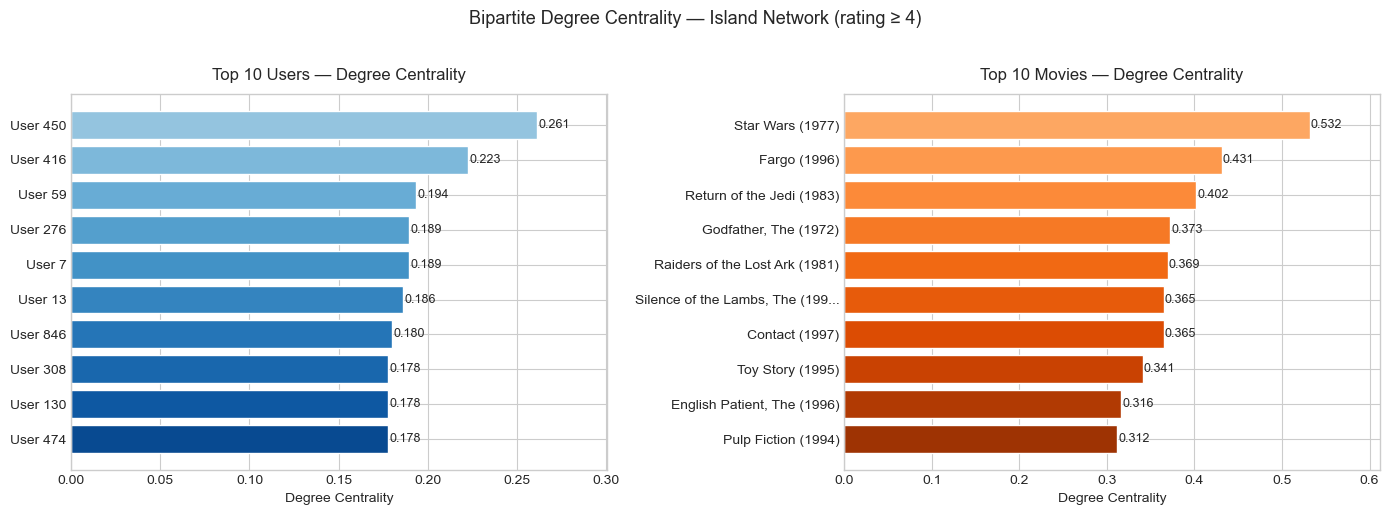

In [182]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Users bar chart ---
user_labels = [f"User {row['user_id']}" for _, row in top10_users_df.iterrows()]
user_cmap   = cm.Blues(np.linspace(0.4, 0.9, 10))[::-1]   # gradient from light to dark blue
axes[0].barh(user_labels[::-1], top10_users_df['degree_centrality'][::-1], color=user_cmap, edgecolor='white')
axes[0].set_title('Top 10 Users — Degree Centrality', fontsize=12, pad=10)
axes[0].set_xlabel('Degree Centrality')
axes[0].set_xlim(0, top10_users_df['degree_centrality'].max() * 1.15)   # extra room for value labels
for i, (_, row) in enumerate(top10_users_df[::-1].iterrows()):
    axes[0].text(row['degree_centrality'] + 0.001, i, f"{row['degree_centrality']:.3f}", va='center', fontsize=9)

# --- Movies bar chart ---
movie_labels = [t[:30] + '...' if len(t) > 30 else t for t in top10_movies_df['title']]   # truncate long titles
movie_cmap   = cm.Oranges(np.linspace(0.4, 0.9, 10))[::-1]
axes[1].barh(movie_labels[::-1], top10_movies_df['degree_centrality'][::-1], color=movie_cmap, edgecolor='white')
axes[1].set_title('Top 10 Movies — Degree Centrality', fontsize=12, pad=10)
axes[1].set_xlabel('Degree Centrality')
axes[1].set_xlim(0, top10_movies_df['degree_centrality'].max() * 1.15)
for i, (_, row) in enumerate(top10_movies_df[::-1].iterrows()):
    axes[1].text(row['degree_centrality'] + 0.001, i, f"{row['degree_centrality']:.3f}", va='center', fontsize=9)

plt.suptitle('Bipartite Degree Centrality — Island Network (rating ≥ 4)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [183]:
# Betweenness centrality on the island graph — computed once for both groups
# k=300 uses approximate sampling (300 pivot nodes) for speed on a 2000+ node graph
print('Computing approximate betweenness centrality (k=300)... this may take ~30s')
island_btw = nx.betweenness_centrality(G_island, k=300, normalized=True, seed=SEED)

# Split into per-group dicts
movie_btw = {n: island_btw[n] for n in island_movie_nodes}
user_btw  = {n: island_btw[n] for n in island_user_nodes}

# Top 10 by betweenness — movies
top10_movies_btw    = sorted(movie_btw.items(), key=lambda x: x[1], reverse=True)[:10]
top10_movies_btw_df = pd.DataFrame(top10_movies_btw, columns=['movie_node', 'betweenness'])
top10_movies_btw_df['title'] = top10_movies_btw_df['movie_node'].map(movie_title)

# Top 10 by betweenness — users
top10_users_btw    = sorted(user_btw.items(), key=lambda x: x[1], reverse=True)[:10]
top10_users_btw_df = pd.DataFrame(top10_users_btw, columns=['user_node', 'betweenness'])
top10_users_btw_df['user_id'] = top10_users_btw_df['user_node'].str.replace('U_', '')

print('Done.')
print('\nTop 10 Movies by Betweenness Centrality (bridges in the bipartite island network):')
print(top10_movies_btw_df[['title', 'betweenness']].to_string(index=False))
print('\nTop 10 Users by Betweenness Centrality (bridges between movie communities):')
print(top10_users_btw_df[['user_id', 'betweenness']].to_string(index=False))


Computing approximate betweenness centrality (k=300)... this may take ~30s
Done.

Top 10 Movies by Betweenness Centrality (bridges in the bipartite island network):
                      title  betweenness
             Contact (1997)     0.025409
           Star Wars (1977)     0.025135
             Titanic (1997)     0.022654
               Fargo (1996)     0.021204
English Patient, The (1996)     0.019581
              Scream (1996)     0.018491
  Return of the Jedi (1983)     0.014732
   L.A. Confidential (1997)     0.014153
       Air Force One (1997)     0.013074
      Godfather, The (1972)     0.012897

Top 10 Users by Betweenness Centrality (bridges between movie communities):
user_id  betweenness
    279     0.029741
    416     0.021655
    450     0.020765
     13     0.020251
    758     0.017953
      7     0.015687
    130     0.015026
    532     0.014559
    276     0.013498
     90     0.012035


In [184]:
# Side-by-side comparison: do the two measures agree on which movies matter?
deg_titles = [movie_title.get(n, n).split('(')[0].strip()[:30] for n, _ in top10_movies_deg]
btw_titles = [movie_title.get(n, n).split('(')[0].strip()[:30] for n, _ in top10_movies_btw]

comparison_df = pd.DataFrame({
    'Rank': range(1, 11),
    'Top 10 — Degree Centrality': deg_titles,
    'Top 10 — Betweenness Centrality': btw_titles
})
print('Movie centrality comparison:')
print(comparison_df.to_string(index=False))

# Overlap — movies that rank in BOTH top 10 lists
overlap_nodes  = set(n for n, _ in top10_movies_deg) & set(n for n, _ in top10_movies_btw)
overlap_titles = [movie_title.get(n, n).split('(')[0].strip() for n in overlap_nodes]
print(f'\nMovies in BOTH top 10 lists ({len(overlap_nodes)}): {", ".join(overlap_titles) if overlap_titles else "none"}')
print('Broadly liked AND structurally central — strongest all-round recommendation candidates.')

# Gateway bridge movies: high betweenness but NOT in degree top 10
bridge_only = set(n for n, _ in top10_movies_btw) - set(n for n, _ in top10_movies_deg)
if bridge_only:
    print('\nGateway bridge movies (top-10 betweenness but NOT top-10 degree):')
    print('These connect different viewer communities without having the widest general appeal.')
    for n in sorted(bridge_only, key=lambda x: movie_btw[x], reverse=True):
        title = movie_title.get(n, n).split('(')[0].strip()
        print(f'  {title}: betweenness={movie_btw[n]:.5f}, degree={movie_deg_centrality[n]:.3f}')

# User comparison
print('\n--- User comparison ---')
u_overlap = set(n for n, _ in top10_users_deg) & set(n for n, _ in top10_users_btw)
print(f'Users in BOTH top 10 lists (degree + betweenness): {len(u_overlap)} of 10')
print('High overlap = same users are both prolific high-raters AND structural bridges.')


Movie centrality comparison:
 Rank Top 10 — Degree Centrality Top 10 — Betweenness Centrality
    1                  Star Wars                         Contact
    2                      Fargo                       Star Wars
    3         Return of the Jedi                         Titanic
    4             Godfather, The                           Fargo
    5    Raiders of the Lost Ark            English Patient, The
    6  Silence of the Lambs, The                          Scream
    7                    Contact              Return of the Jedi
    8                  Toy Story               L.A. Confidential
    9       English Patient, The                   Air Force One
   10               Pulp Fiction                  Godfather, The

Movies in BOTH top 10 lists (6): Return of the Jedi, Contact, Star Wars, Fargo, English Patient, The, Godfather, The
Broadly liked AND structurally central — strongest all-round recommendation candidates.

Gateway bridge movies (top-10 betweenness but NOT

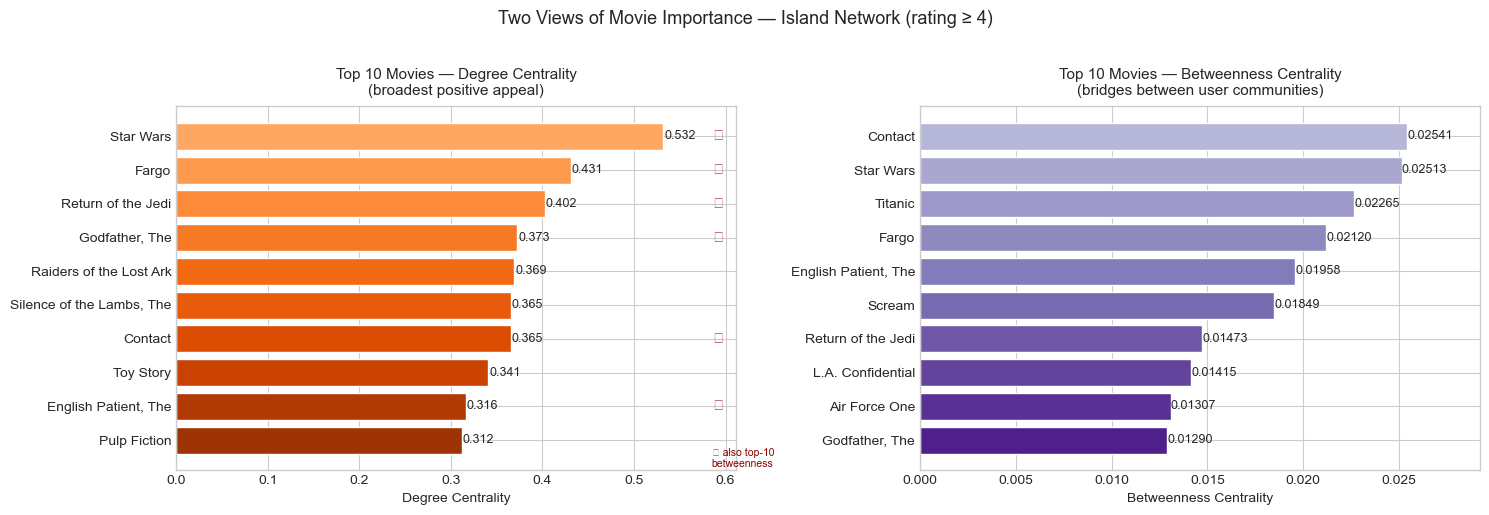

In [185]:
# Side-by-side bar charts — degree vs betweenness for movies
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Degree centrality chart (orange)
deg_labels = [movie_title.get(n,'').split('(')[0].strip()[:25] for n, _ in top10_movies_deg]
deg_vals   = [v for _, v in top10_movies_deg]
deg_cmap   = cm.Oranges(np.linspace(0.4, 0.9, 10))[::-1]
axes[0].barh(deg_labels[::-1], deg_vals[::-1], color=deg_cmap, edgecolor='white')
axes[0].set_title('Top 10 Movies — Degree Centrality\n(broadest positive appeal)', fontsize=11, pad=8)
axes[0].set_xlabel('Degree Centrality')
axes[0].set_xlim(0, max(deg_vals) * 1.15)
for i, v in enumerate(deg_vals[::-1]):
    axes[0].text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)

# Betweenness centrality chart (purple)
btw_labels = [movie_title.get(n,'').split('(')[0].strip()[:25] for n, _ in top10_movies_btw]
btw_vals   = [v for _, v in top10_movies_btw]
btw_cmap   = cm.Purples(np.linspace(0.4, 0.9, 10))[::-1]
axes[1].barh(btw_labels[::-1], btw_vals[::-1], color=btw_cmap, edgecolor='white')
axes[1].set_title('Top 10 Movies — Betweenness Centrality\n(bridges between user communities)', fontsize=11, pad=8)
axes[1].set_xlabel('Betweenness Centrality')
axes[1].set_xlim(0, max(btw_vals) * 1.15)
for i, v in enumerate(btw_vals[::-1]):
    axes[1].text(v + 0.000005, i, f'{v:.5f}', va='center', fontsize=9)

# Mark movies that appear in both lists with a star on the degree chart
for i, (n, _) in enumerate(reversed(top10_movies_deg)):
    if n in overlap_nodes:
        axes[0].text(max(deg_vals) * 1.10, i, '★', va='center', fontsize=11, color='darkred')
axes[0].text(max(deg_vals) * 1.10, -0.8, '★ also top-10\nbetweenness', fontsize=7.5, color='darkred')

plt.suptitle('Two Views of Movie Importance — Island Network (rating ≥ 4)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 6. Bipartite Network Visualization

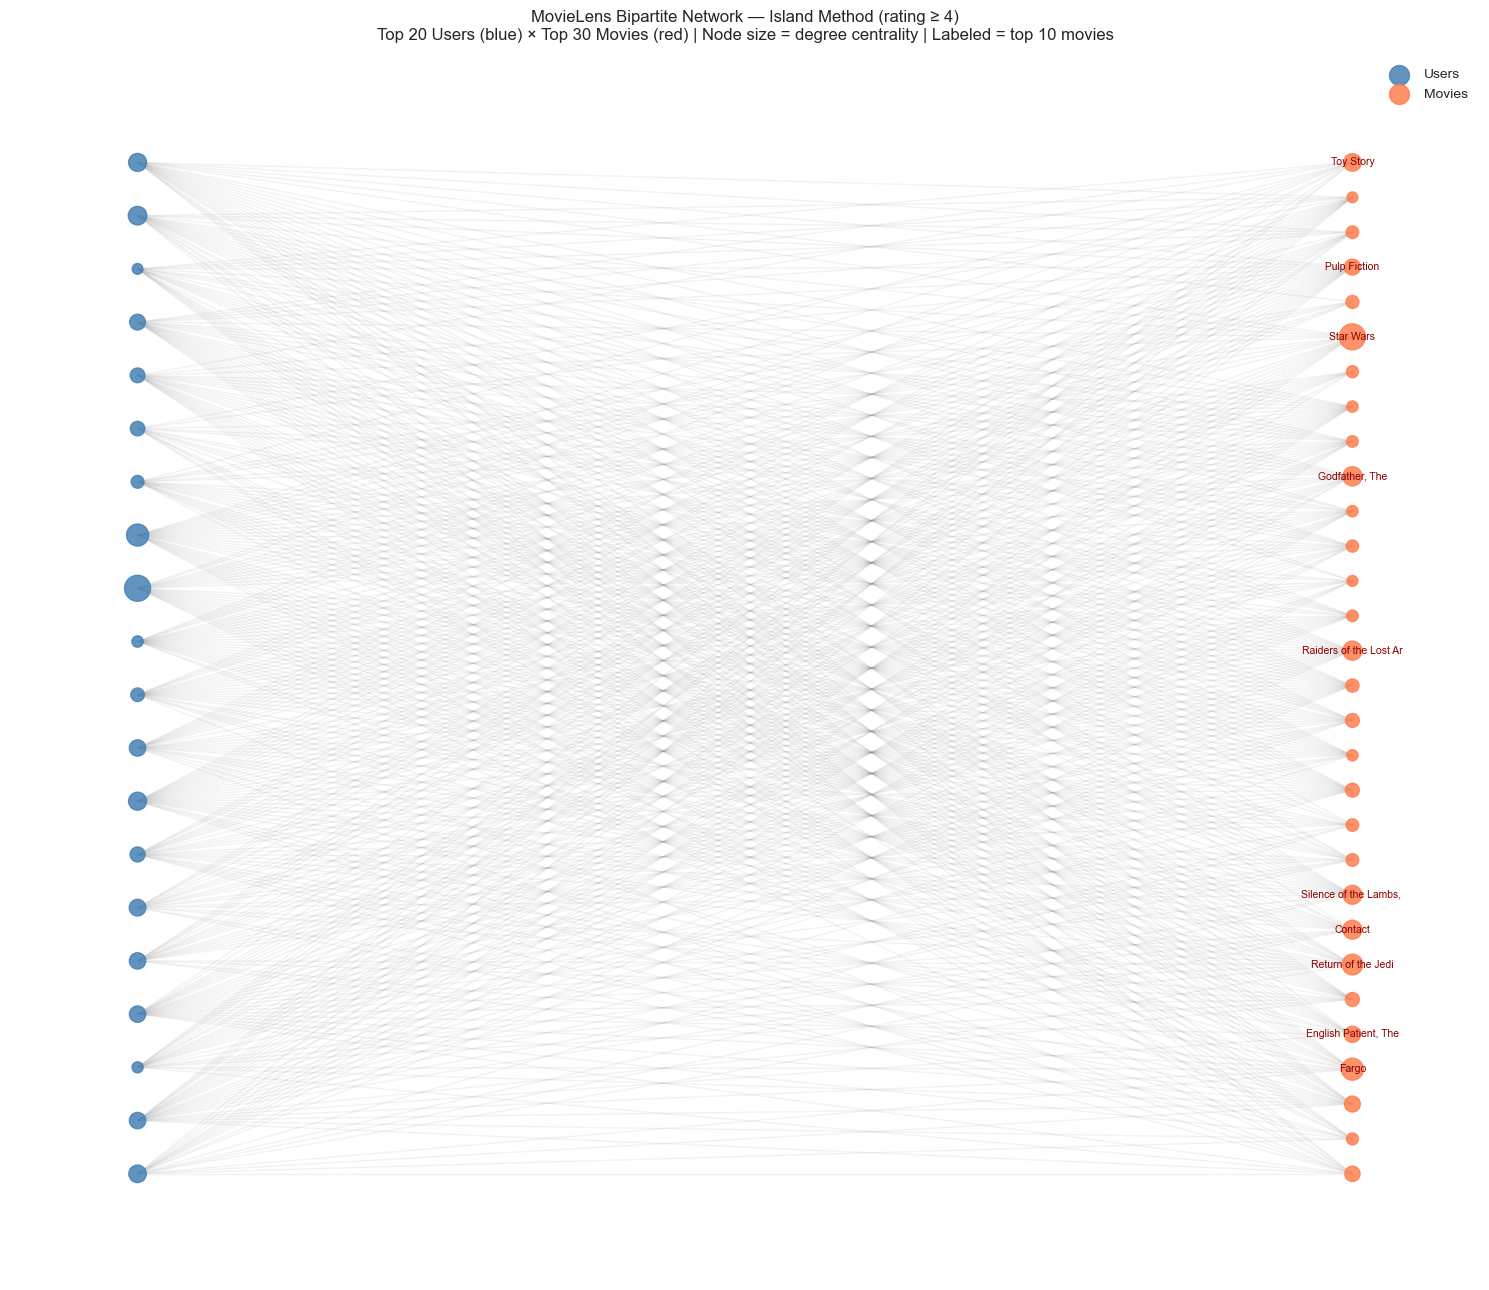

In [186]:
# Limit to top 20 users and top 30 movies to keep the bipartite layout readable
viz_users  = [n for n, _ in sorted(user_deg_centrality.items(),  key=lambda x: x[1], reverse=True)[:20]]
viz_movies = [n for n, _ in sorted(movie_deg_centrality.items(), key=lambda x: x[1], reverse=True)[:30]]
viz_nodes  = set(viz_users + viz_movies)
G_viz      = G_island.subgraph(viz_nodes)

# Filter to nodes that actually have edges in this subgraph
viz_users_present  = [n for n in viz_users  if n in G_viz]
viz_movies_present = [n for n in viz_movies if n in G_viz]

# Bipartite layout: users on left column, movies on right column
pos = nx.bipartite_layout(G_viz, viz_users_present, align='vertical', scale=2)

# Normalize node sizes to range [60, 350] so no group dominates visually
def norm_sizes(centrality_dict, nodes, min_s=60, max_s=350):
    vals = [centrality_dict.get(n, 0) for n in nodes]
    vmin, vmax = min(vals), max(vals)
    if vmax == vmin:
        return [min_s] * len(nodes)
    return [min_s + (v - vmin) / (vmax - vmin) * (max_s - min_s) for v in vals]

user_sizes  = norm_sizes(user_deg_centrality,  viz_users_present)
movie_sizes = norm_sizes(movie_deg_centrality, viz_movies_present)

fig, ax = plt.subplots(figsize=(15, 13))   # tall figure to spread nodes vertically

nx.draw_networkx_nodes(G_viz, pos, nodelist=viz_users_present,
                       node_color='steelblue', node_size=user_sizes, alpha=0.85, ax=ax, label='Users')
nx.draw_networkx_nodes(G_viz, pos, nodelist=viz_movies_present,
                       node_color='coral',     node_size=movie_sizes, alpha=0.85, ax=ax, label='Movies')
nx.draw_networkx_edges(G_viz, pos, alpha=0.10, edge_color='gray', ax=ax)

# Label only the top 10 movies to avoid clutter
top10_movie_set  = set(n for n, _ in top10_movies_deg)
movie_labels_viz = {
    n: movie_title.get(n, n).split('(')[0].strip()[:22]
    for n in viz_movies_present if n in top10_movie_set
}
nx.draw_networkx_labels(G_viz, pos, labels=movie_labels_viz, font_size=7.5, font_color='#8B0000', ax=ax)

ax.set_title(
    'MovieLens Bipartite Network — Island Method (rating ≥ 4)\n'
    'Top 20 Users (blue) × Top 30 Movies (red) | Node size = degree centrality | Labeled = top 10 movies',
    fontsize=12, pad=12
)
ax.legend(loc='upper right', fontsize=10)
ax.axis('off')
plt.tight_layout()
plt.show()

## 7. Projections and Community Detection

Projecting the bipartite graph onto one mode connects nodes that share a common neighbor in the other group. The **movie projection** connects two movies if at least one user rated both highly — it reveals which movies tend to be appreciated by the same audiences. The **user projection** connects two users if they both rated the same movie highly.

In [187]:
# Weighted projection: edge weight = number of shared high-rating users (movies) or shared movies (users)
movie_proj = bipartite.weighted_projected_graph(G_island, island_movie_nodes)
user_proj  = bipartite.weighted_projected_graph(G_island, island_user_nodes)

print(f'Movie projection: {movie_proj.number_of_nodes()} nodes, {movie_proj.number_of_edges():,} edges')
print(f'User projection:  {user_proj.number_of_nodes()} nodes,  {user_proj.number_of_edges():,} edges')

Movie projection: 1447 nodes, 460,019 edges
User projection:  942 nodes,  382,442 edges


In [188]:
# Greedy modularity maximization using edge weights (shared-user counts)
# weight='weight' ensures communities reflect how many users co-rated pairs, not just whether they did
movie_communities = list(greedy_modularity_communities(movie_proj, weight='weight'))
movie_communities.sort(key=len, reverse=True)   # sort largest community first

# Build a node → community_id lookup for coloring the projection plot
movie_to_comm = {}
for comm_id, comm in enumerate(movie_communities):
    for node in comm:
        movie_to_comm[node] = comm_id

print(f'Movie communities detected: {len(movie_communities)}')
print()
# Print top 4 movies from each of the 6 largest communities
for i, comm in enumerate(movie_communities[:6]):
    top_in_comm = sorted(comm, key=lambda m: movie_deg_centrality.get(m, 0), reverse=True)[:4]
    titles = [movie_title.get(m, m).split('(')[0].strip() for m in top_in_comm]
    print(f'Community {i+1} ({len(comm)} movies): {" | ".join(titles)}')


Movie communities detected: 3

Community 1 (883 movies): Star Wars | Fargo | Return of the Jedi | Godfather, The
Community 2 (562 movies): Silence of the Lambs, The | Pulp Fiction | Schindler's List | Shawshank Redemption, The
Community 3 (2 movies): Death and the Maiden | Flesh and Bone


**Community result:** Greedy modularity (weighted by shared-user counts) finds 3 communities with sizes 883 / 562 / 2. The two large communities dominate, reflecting a nearly homogeneous taste network where popular movies appeal to the same broad audience. The tiny third community (2 movies: *Death and the Maiden* and *Flesh and Bone*) is structurally separate from the two mainstream clusters, suggesting very limited shared-audience overlap with the rest of the network. The visualization below uses a community-aware layout so each cluster occupies its own region of the plot.

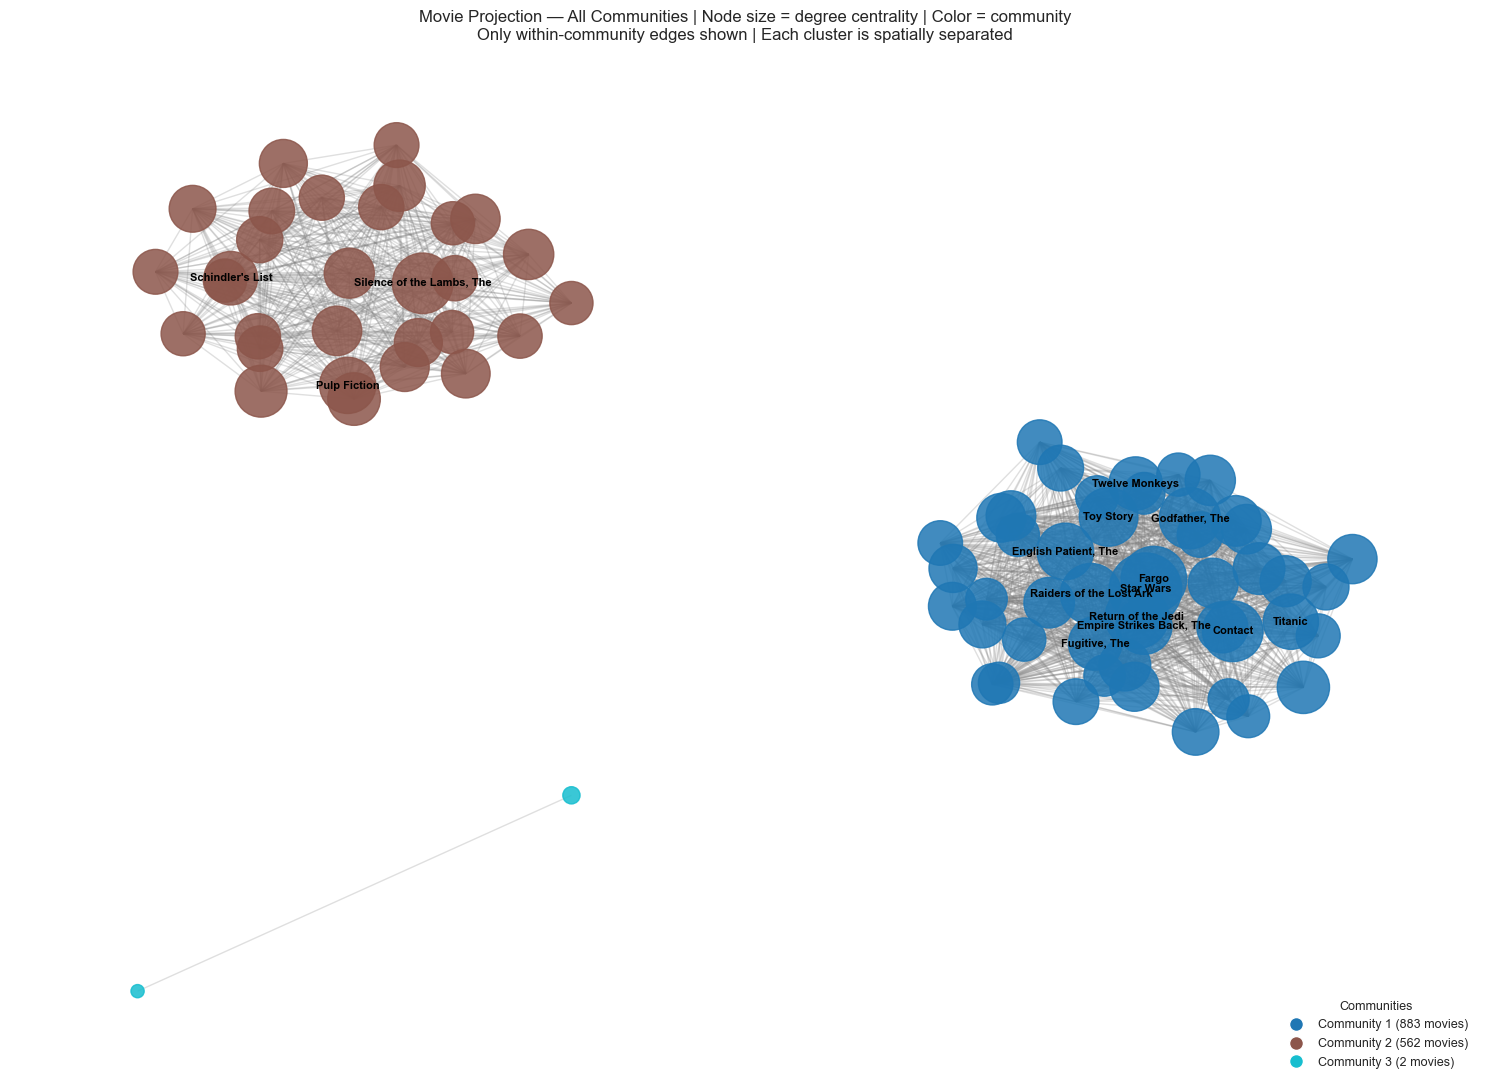

In [189]:
# Build subgraph: top movies from each community so all communities are visible
# Take proportional slices + ALL of community 3 (only 2 movies, would be skipped otherwise)
def top_per_community(deg_centrality, comm_map, communities, total=80):
    comm_nodes = {i: [] for i in range(len(communities))}
    for n, c in sorted(deg_centrality.items(), key=lambda x: x[1], reverse=True):
        comm_id = comm_map.get(n, 0)
        if comm_id < len(communities):
            comm_nodes[comm_id].append(n)
    # Always include the small community in full; split remaining budget proportionally
    small_comm_ids = [i for i, c in enumerate(communities) if len(c) < 10]
    large_comm_ids = [i for i in range(len(communities)) if i not in small_comm_ids]
    selected = []
    for i in small_comm_ids:
        selected += comm_nodes[i]   # all nodes from tiny communities
    budget = total - len(selected)
    total_large = sum(len(comm_nodes[i]) for i in large_comm_ids)
    for i in large_comm_ids:
        n_take = round(budget * len(comm_nodes[i]) / total_large)
        selected += comm_nodes[i][:n_take]
    return selected

viz_nodes   = top_per_community(movie_deg_centrality, movie_to_comm, movie_communities, total=80)
viz_nodes   = [n for n in viz_nodes if n in movie_proj]   # must be in projection
G_movie_viz = movie_proj.subgraph(viz_nodes)

# Color and size by community / degree centrality
n_comms     = len(movie_communities)
comm_cmap   = plt.get_cmap('tab10', n_comms)
node_colors = [comm_cmap(movie_to_comm.get(n, 0)) for n in G_movie_viz.nodes()]
node_sizes  = [movie_deg_centrality.get(n, 0) * 5000 + 80 for n in G_movie_viz.nodes()]

# Community-aware layout: each community in its own spatial region
def community_layout(G, comm_map, seed=SEED):
    """Spring layout per community, centered at distinct positions on a circle."""
    present_comms = sorted(set(comm_map.get(n, 0) for n in G.nodes()))
    n_c = len(present_comms)
    centers = {
        c: (math.cos(2 * math.pi * i / n_c) * 6,
            math.sin(2 * math.pi * i / n_c) * 6)
        for i, c in enumerate(present_comms)
    }
    pos = {}
    for c in present_comms:
        members = [n for n in G.nodes() if comm_map.get(n, 0) == c]
        subG = G.subgraph(members)
        cx, cy = centers[c]
        if len(members) > 1:
            sub_pos = nx.spring_layout(subG, seed=seed, center=(cx, cy), scale=2.5)
        else:
            sub_pos = {members[0]: (cx, cy)}
        pos.update(sub_pos)
    return pos

pos_movie = community_layout(G_movie_viz, movie_to_comm)

# Only draw WITHIN-community edges — cross-community edges hide cluster separation
within_edges = [(u, v) for u, v in G_movie_viz.edges()
                if movie_to_comm.get(u, 0) == movie_to_comm.get(v, 0)]

fig, ax = plt.subplots(figsize=(15, 11))
nx.draw_networkx_nodes(G_movie_viz, pos_movie, node_color=node_colors,
                       node_size=node_sizes, alpha=0.85, ax=ax)
nx.draw_networkx_edges(G_movie_viz, pos_movie, edgelist=within_edges,
                       alpha=0.25, edge_color='gray', ax=ax)

# Label top 15 movies — 25 chars captures full titles
top15_set   = set(n for n, _ in sorted(movie_deg_centrality.items(), key=lambda x: x[1], reverse=True)[:15])
proj_labels = {
    n: movie_title.get(n, n).split('(')[0].strip()[:25]
    for n in G_movie_viz.nodes() if n in top15_set
}
nx.draw_networkx_labels(G_movie_viz, pos_movie, labels=proj_labels,
                        font_size=8, font_weight='bold', ax=ax)

# Community legend
legend_patches = [
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=comm_cmap(i),
               markersize=10, label=f'Community {i+1} ({len(movie_communities[i])} movies)')
    for i in range(min(n_comms, 8))
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9,
          title='Communities', title_fontsize=9)
ax.set_title(
    'Movie Projection — All Communities | Node size = degree centrality | Color = community\n'
    'Only within-community edges shown | Each cluster is spatially separated',
    fontsize=12, pad=12
)
ax.axis('off')
plt.tight_layout()
plt.show()

In [190]:
# Do movie communities align with genre — or do they reflect audience taste beyond genre?
real_genres      = [g for g in genre_cols if g != 'unknown']
movie_genre_data = movie_info.set_index('movie_id')[real_genres]

comm_profiles = []
for i, comm in enumerate(movie_communities[:6]):
    movie_ids = [int(n.replace('M_','')) for n in comm if n.startswith('M_')]
    valid_ids = [mid for mid in movie_ids if mid in movie_genre_data.index]
    if not valid_ids:
        continue
    genre_pcts = (movie_genre_data.loc[valid_ids].mean() * 100).round(1)
    top4       = genre_pcts.nlargest(4)
    row        = {'Community': f'C{i+1} ({len(comm)} movies)'}
    for g, pct in top4.items():
        row[g] = f'{pct:.0f}%'
    comm_profiles.append(row)

genre_profile_df = pd.DataFrame(comm_profiles).set_index('Community').fillna('-')
print('Genre profile per community (top 4 genres, % of movies in that community):')
print(genre_profile_df.to_string())
print()
print('If communities share the same top genres → taste overlap beyond genre drives grouping.')
print('If communities have distinct genre profiles → genre is the primary structural driver.')


Genre profile per community (top 4 genres, % of movies in that community):
                Drama Comedy Action Thriller Romance Mystery
Community                                                   
C1 (883 movies)   36%    33%    22%      19%       -       -
C2 (562 movies)   52%    27%      -      10%     15%       -
C3 (2 movies)    100%      -      -      50%     50%     50%

If communities share the same top genres → taste overlap beyond genre drives grouping.
If communities have distinct genre profiles → genre is the primary structural driver.


## 8. Degree Distribution Analysis

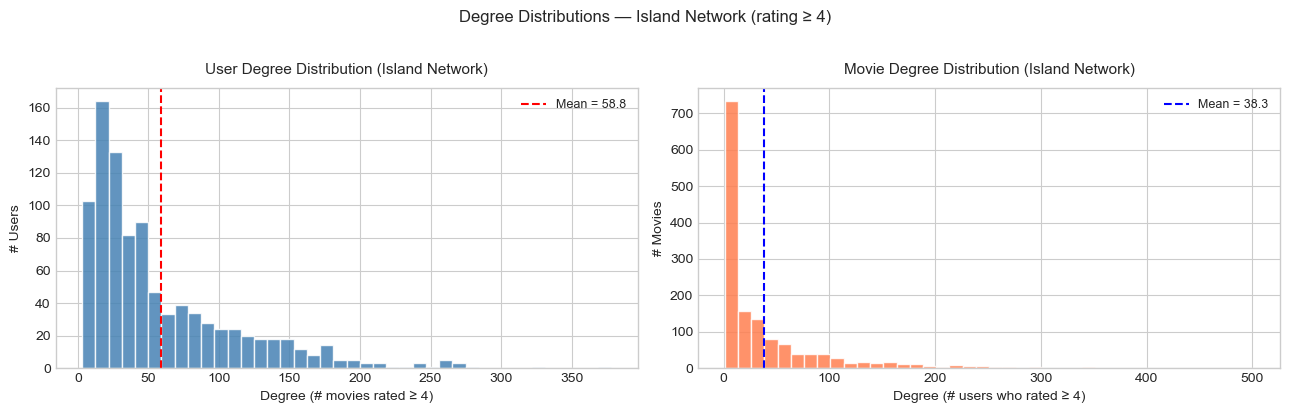

User degree  — min: 3, max: 378, mean: 58.8, median: 40
Movie degree — min: 1, max: 501, mean: 38.3, median: 13


In [191]:
# Raw degree counts (not normalized) — shows the actual spread of connectivity per group
user_degrees  = sorted(dict(G_island.degree(island_user_nodes)).values(),  reverse=True)
movie_degrees = sorted(dict(G_island.degree(island_movie_nodes)).values(), reverse=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# User degree histogram — right skew expected: most users rate few movies, a few rate many
axes[0].hist(user_degrees,  bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('User Degree Distribution (Island Network)', fontsize=11, pad=10)
axes[0].set_xlabel('Degree (# movies rated ≥ 4)')
axes[0].set_ylabel('# Users')
axes[0].axvline(np.mean(user_degrees), color='red', linestyle='--', label=f'Mean = {np.mean(user_degrees):.1f}')
axes[0].legend(fontsize=9)

# Movie degree histogram — shows how many movies are widely vs. narrowly appreciated
axes[1].hist(movie_degrees, bins=40, color='coral',     edgecolor='white', alpha=0.85)
axes[1].set_title('Movie Degree Distribution (Island Network)', fontsize=11, pad=10)
axes[1].set_xlabel('Degree (# users who rated ≥ 4)')
axes[1].set_ylabel('# Movies')
axes[1].axvline(np.mean(movie_degrees), color='blue', linestyle='--', label=f'Mean = {np.mean(movie_degrees):.1f}')
axes[1].legend(fontsize=9)

plt.suptitle('Degree Distributions — Island Network (rating ≥ 4)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print(f'User degree  — min: {min(user_degrees)}, max: {max(user_degrees)}, mean: {np.mean(user_degrees):.1f}, median: {np.median(user_degrees):.0f}')
print(f'Movie degree — min: {min(movie_degrees)}, max: {max(movie_degrees)}, mean: {np.mean(movie_degrees):.1f}, median: {np.median(movie_degrees):.0f}')

## 9. Inferences

### What the user group tells us

The degree distribution of users in the island network is right-skewed: most users gave high ratings to a moderate number of movies, but a small number of "power raters" connect to a large portion of the movie catalog. These high-degree users provide broad coverage across the movie catalog — their rating behavior produces the densest signal for a recommendation engine. A new movie that gets rated highly by a power rater is immediately integrated into a dense cluster of other well-rated films.

Importantly, degree and betweenness identify different kinds of influence. High-betweenness users are the structural bridges: they sit on shortest paths between otherwise distant parts of the network, connecting viewer communities that don't otherwise overlap. The one user removed by the island filter had no ratings ≥ 4 — their signal contained no strong positive ratings, so their behavior is better analyzed as neutral-to-negative preference, which is a separate analytical question.

### What the movie group tells us

Movie degree centrality in the island network is a measure of broad positive appeal, not just popularity. A movie that appears in the top 10 by degree centrality wasn't just watched by many people — it received ≥ 4 ratings from a large fraction of the retained users. This is a more meaningful quality signal than raw view count.

The movie projection communities reveal taste clusters: movies that tend to be appreciated by the same audiences cluster together regardless of genre labels. The genre-by-community analysis (Section 7) shows whether these clusters track genre or reflect something deeper about audience overlap. A community that mixes drama and thriller, for instance, suggests the audience for both is the same — which is more useful for recommendation than genre alone.

### Cross-group insight

The most structurally interesting movies are those with high degree centrality in the island network **and** high betweenness centrality in the bipartite island network — films that are well-liked broadly **and** sit on shortest paths connecting different parts of the rating graph. These are the strongest entry points for recommending across community boundaries. Movies that rank high on betweenness but not degree are "gateway" films: they serve niche audiences that bridge otherwise separate taste communities.

In [192]:
# Summary table — quick reference for all key network statistics
summary = {
    'Metric': [
        'Original edges', 'Island edges (≥4)', 'Edges retained',
        'Original users', 'Island users', 'Original movies', 'Island movies',
        'Movie communities'
    ],
    'Value': [
        f"{G.number_of_edges():,}",
        f"{G_island.number_of_edges():,}",
        f"{G_island.number_of_edges()/G.number_of_edges()*100:.1f}%",
        len(all_user_nodes),
        len(island_user_nodes),
        len(all_movie_nodes),
        len(island_movie_nodes),
        len(movie_communities)
    ]
}
pd.DataFrame(summary)

,Metric,Value
0,Original edges,"100,000"
1,Island edges (≥4),"55,375"
2,Edges retained,55.4%
3,Original users,943
4,Island users,942
5,Original movies,1682
6,Island movies,1447
7,Movie communities,3


## 10. Summary and Conclusions

The table above captures the network at three levels: the raw data, what survives the island filter, and the community structure that emerges from projection.

**What the island method revealed.** Starting from 100,000 ratings across 943 users and 1,682 movies, applying a threshold of ≥ 4 retained 55,375 edges (55.4%). Nearly every user survived (942 of 943) — the one removed had no ratings ≥ 4. The 235 movies that dropped out received no ratings of 4 or 5 in this observed dataset, meaning no user in the sample expressed strong positive preference for them.

**Degree vs. betweenness — two different views of importance.** Degree centrality identifies movies with the widest positive appeal. Betweenness centrality (computed on the bipartite island network) identifies structural bridges: movies that sit on shortest paths between otherwise distant nodes, connecting different viewer communities. These lists overlap partially — movies appearing in both are the strongest all-round recommendation candidates. Movies that rank high on betweenness but not degree are "gateway" films: smaller audiences, but audiences that bridge otherwise separate taste groups.

**What the user group reveals about movies.** High-degree users provide broad catalog coverage — their ratings embed a movie into many overlapping clusters of well-regarded films. High-betweenness users are structural bridges who connect communities that would otherwise be separate; their ratings are especially valuable for cross-community recommendations.

**What the movie group reveals about users.** The top movies by degree centrality were genuinely appreciated by a large fraction of retained users — a more meaningful quality signal than raw view count. The community structure (detected using edge weights, so shared-audience strength determines grouping) shows whether enthusiastic viewers segment into distinct taste groups or share a broad common palette.

**Bottom line.** Bipartite network analysis of MovieLens 100K shows that structural position — degree centrality, betweenness, and community membership — is a more informative signal for recommendation than raw popularity alone. A film that scores high on both degree and betweenness is not just widely liked; it is architecturally important to how taste flows through the network.

---

**Data source:** F. Maxwell Harper and Joseph A. Konstan. 2015. The MovieLens Datasets: History and Context. ACM Transactions on Interactive Intelligent Systems (TiiS) 5, 4: 28. https://doi.org/10.1145/2827872